In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import csv
import pandas as pd
import os
import math

In [2]:
G = nx.DiGraph()

with open("D:/SEM VI/Project/Dataset/single_topic/edges.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        G.add_edge(
            int(row["u"]), 
            int(row["v"]),
            trust = float(row["trust"])
        )


with open("D:/SEM VI/Project/Dataset/single_topic/nodes1.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        node = int(row["node"])
        threshold = float(row["threshold"])
        opinion = row["opinion"].strip() if row["opinion"] else None

        G.add_node(node)
        G.nodes[node]["threshold"] = threshold
        G.nodes[node]["opinion"] = opinion

In [3]:
opinion_colors = {
    "A": "red",
    "B": "blue",
    "C": "green",
    "U": "lightgray"
}

opinion_weight = {
    "A": 0.9,
    "B": 0.6,
    "C": 0.4
}

ALPHA = 0.6
BETA = 0.3
GAMMA = 0.4

In [4]:
CONFIRMATION_BIAS = True

def resistance(node, new_op, prev_op):
    if prev_op is None or prev_op == new_op:
        return 0.0
    return 1.0

def directed_multi_opinion_step(G):
    prev_opinion = {n: G.nodes[n]["opinion"] for n in G.nodes()}
    updates = {}

    for v in G.nodes():
        incoming = list(G.predecessors(v))
        if not incoming:
            continue

        # assignment - with and without confirmation bias
        weighted_sum = {}
        total_trust = 0.0

        for u in incoming:
            op_u = prev_opinion[u]

            # undecided neighbors do not influence
            if op_u == "U":
                continue

            trust = G[u][v]["trust"]

            if CONFIRMATION_BIAS and prev_opinion[v] != "U":
                diff = abs(opinion_weight[op_u] - opinion_weight[prev_opinion[v]])
                confirmation_weight = math.exp(-ALPHA * diff)
            else:
                confirmation_weight = 1.0

            influence = trust * opinion_weight[op_u] * confirmation_weight
            weighted_sum[op_u] = weighted_sum.get(op_u, 0) + influence
            total_trust += trust

        if total_trust == 0:
            continue

        scores = {
            op: val / total_trust
            for op, val in weighted_sum.items()
        }
        #

        valid_ops = [
            op for op, score in scores.items()
            if score >= G.nodes[v]["threshold"]
        ]

        if valid_ops:
            updates[v] = max(valid_ops, key=lambda o: scores[o])

    return updates, prev_opinion

In [5]:
def export_to_excel(G, iteration, prev_opinion,
                    out_dir="D:/SEM VI/Project/Dataset/updateexcel"):
    os.makedirs(out_dir, exist_ok=True)

    node_rows = []
    for n in G.nodes():
        node_rows.append({
            "node": n,
            "opinion_changed": prev_opinion.get(n) != G.nodes[n]["opinion"],
            "threshold": G.nodes[n]["threshold"],
            "iteration": iteration
        })

    pd.DataFrame(node_rows).to_excel(
        f"{out_dir}/nodes_iter_{iteration}.xlsx",
        index=False
    )

    edge_rows = [{"source": u, "target": v} for u, v in G.edges()]
    pd.DataFrame(edge_rows).to_excel(
        f"{out_dir}/edges_iter_{iteration}.xlsx",
        index=False
    )

In [6]:
pos = nx.spring_layout(G, seed=42)

def plot_iteration(G, iteration):
    colors = [opinion_colors[G.nodes[n]["opinion"]] for n in G.nodes()]
    labels = {n: f"{n}\n{G.nodes[n]['opinion']}" for n in G.nodes()}

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, node_color=colors, node_size=800, edge_color="gray", arrows=True)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    plt.title(f"Iteration {iteration}")
    plt.show()

Iteration 1: 14 real opinion changes


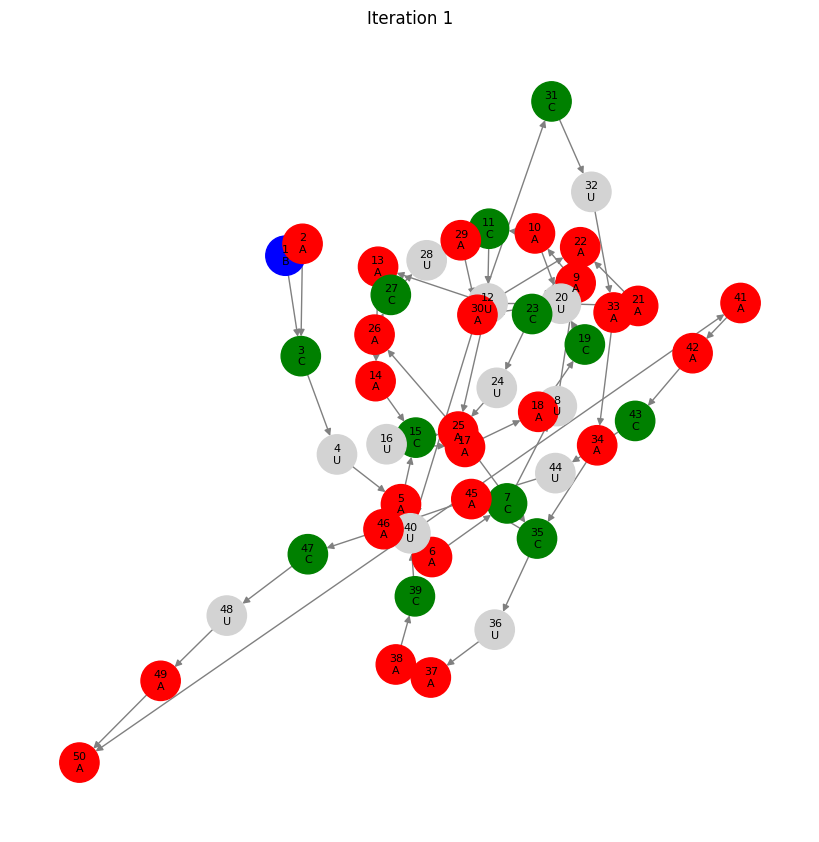

Iteration 2: 11 real opinion changes


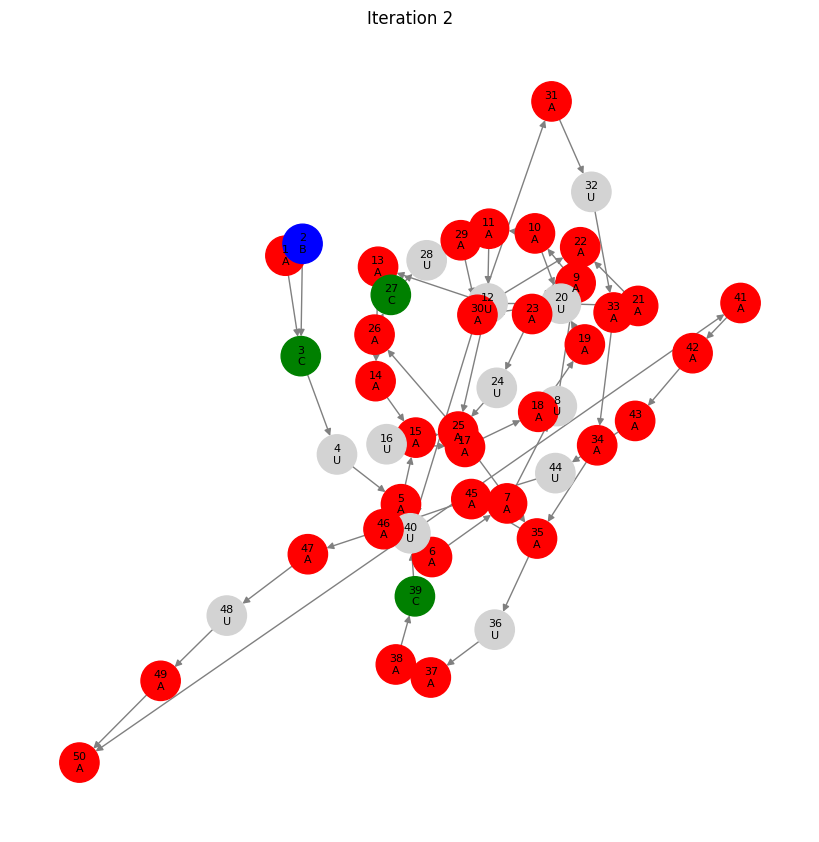

Iteration 3: 11 real opinion changes


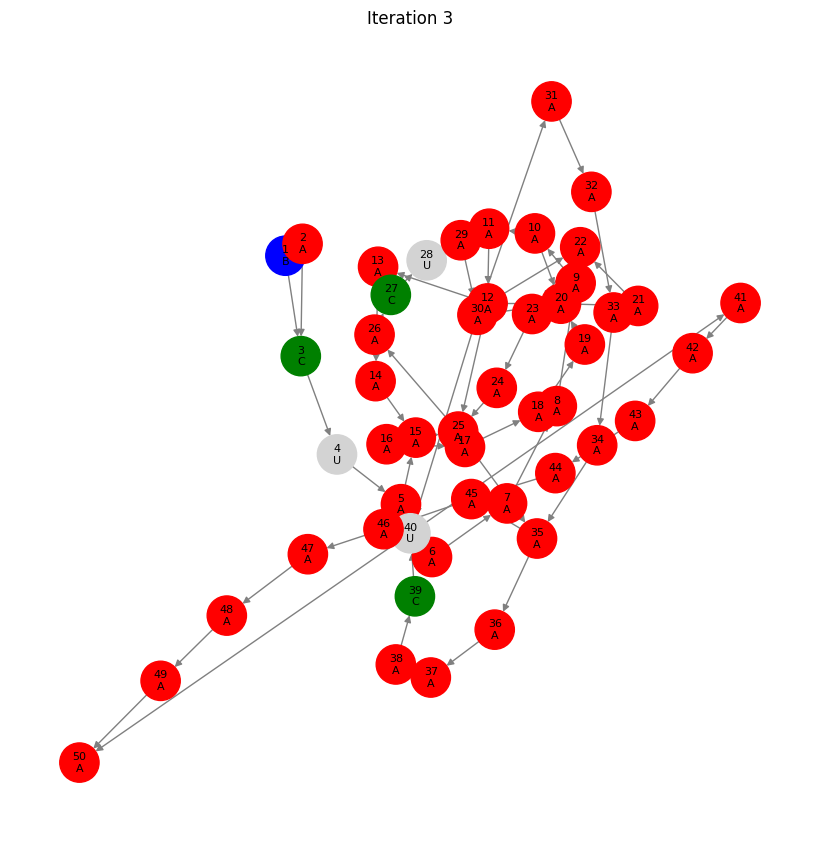

Iteration 4: 2 real opinion changes


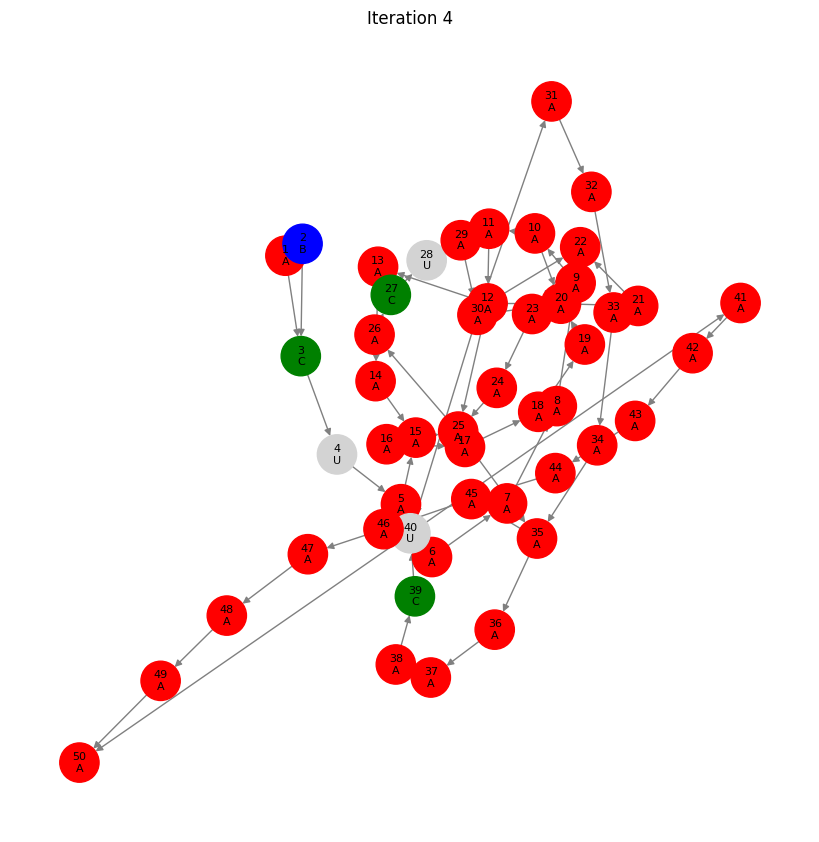

Iteration 5: 2 real opinion changes


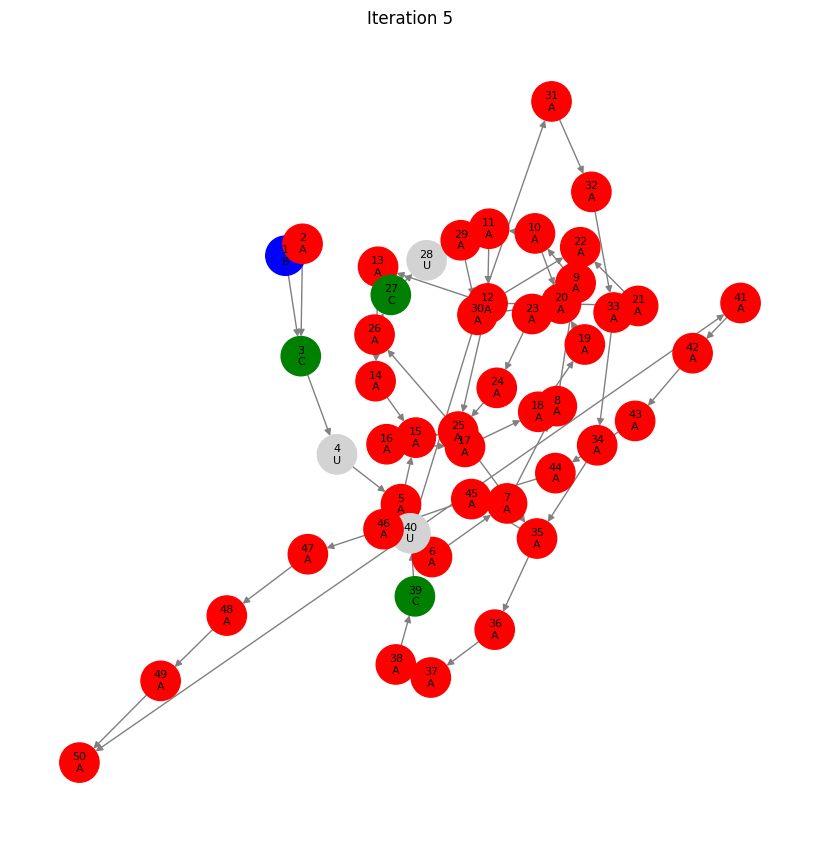

Iteration 6: 2 real opinion changes


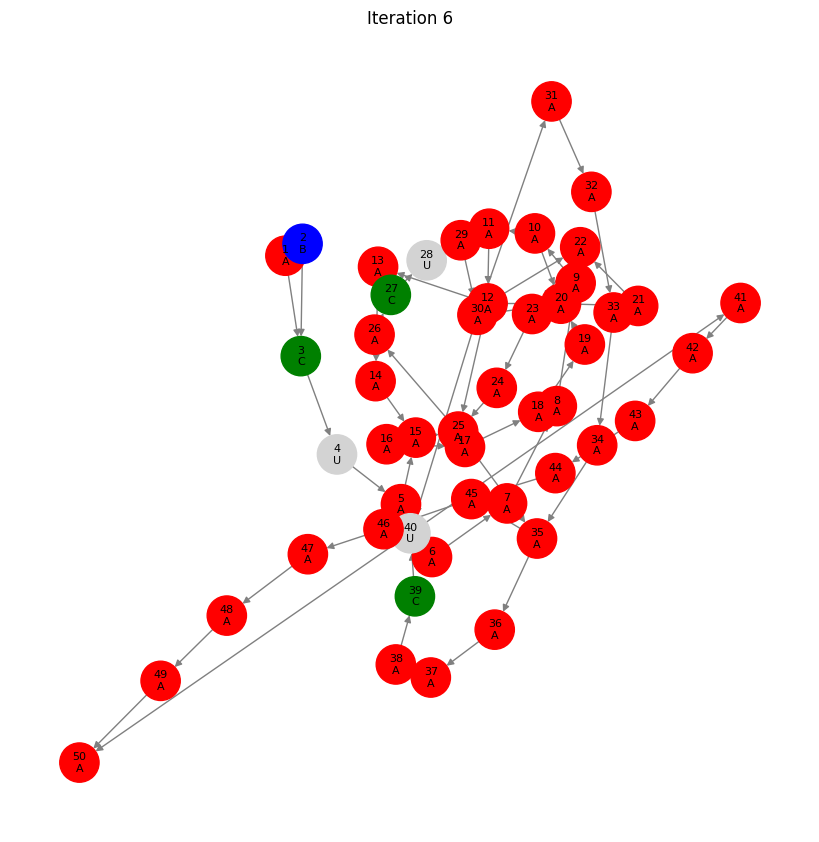

Iteration 7: 2 real opinion changes


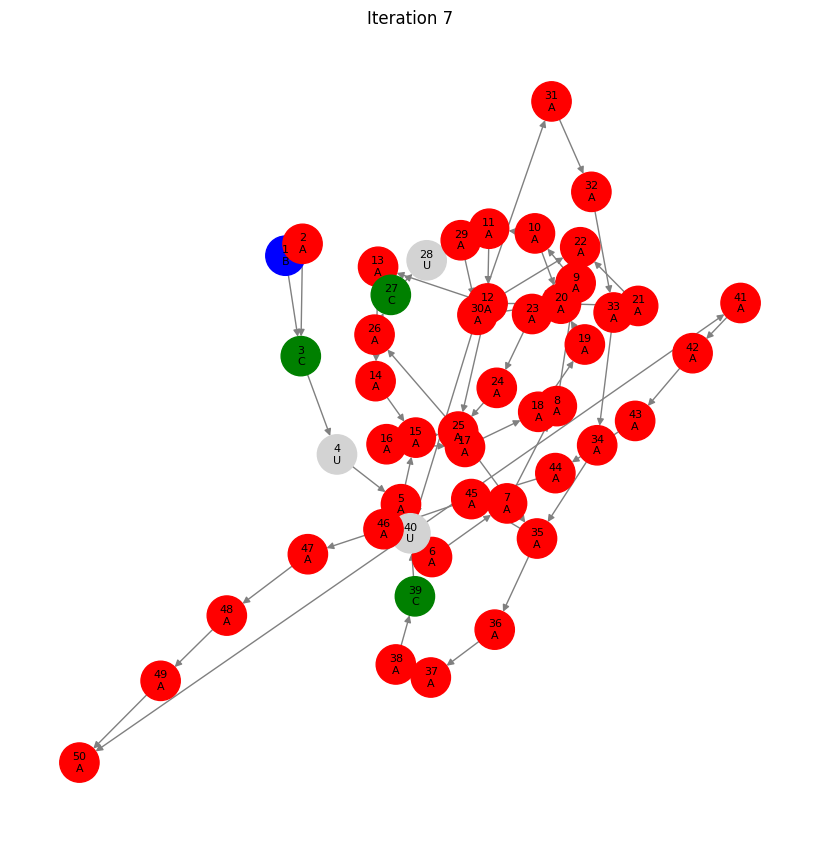

Iteration 8: 2 real opinion changes


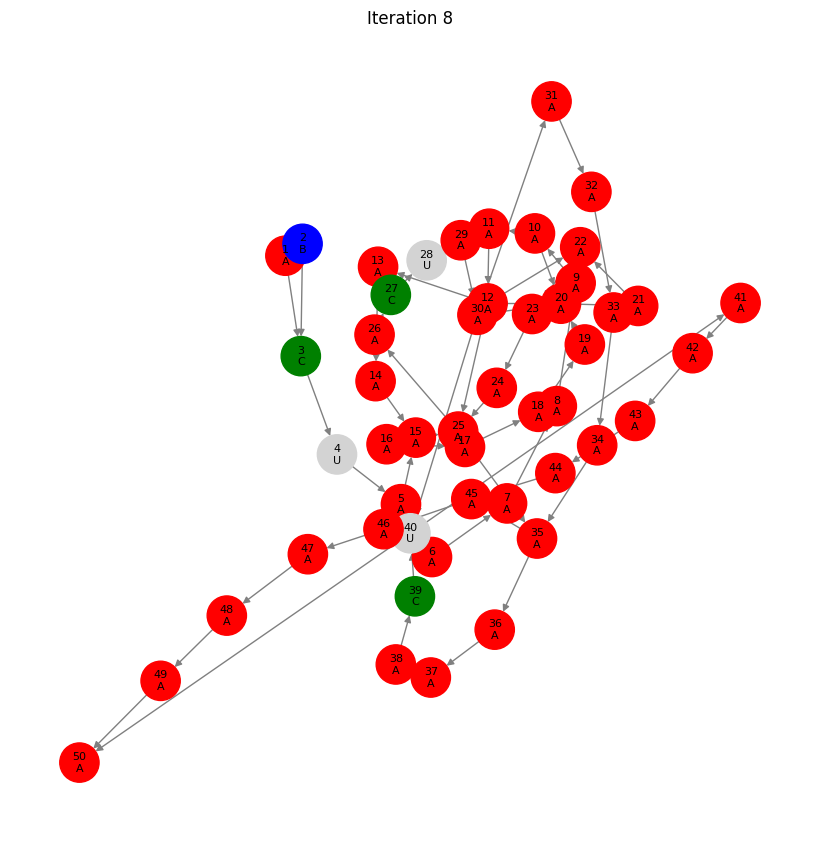

Iteration 9: 2 real opinion changes


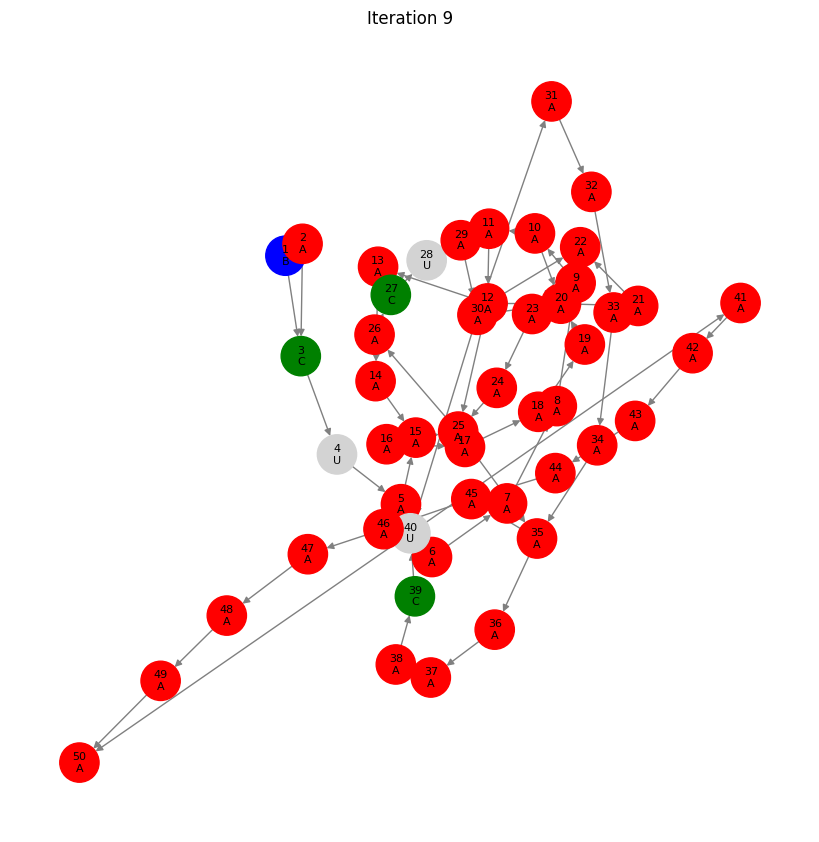

Iteration 10: 2 real opinion changes


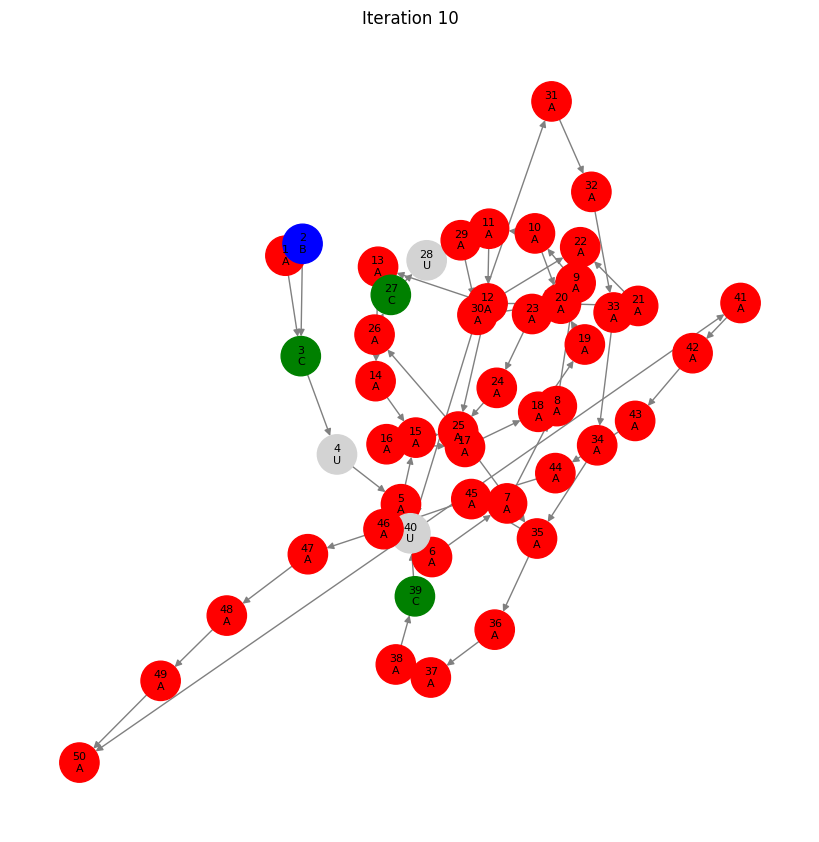

In [7]:
MAX_ITER = 10

for i in range(1, MAX_ITER + 1):
    updates, prev_opinion = directed_multi_opinion_step(G)

    real_changes = {
        node: op for node, op in updates.items()
        if prev_opinion[node] != op
    }

    print(f"Iteration {i}: {len(real_changes)} real opinion changes")

    if not real_changes:
        print("No new opinion changes. Converged.")
        export_to_excel(G, i, prev_opinion)
        plot_iteration(G, i)
        break

    for node, op in real_changes.items():
        G.nodes[node]["opinion"] = op

    export_to_excel(G, i, prev_opinion)
    plot_iteration(G, i)

The network converged to a stable opinion distribution — meaning agents stopped changing opinions once social influence could no longer overcome individual resistance.
Agents with lower resistance adopted new opinions early in the process, while more resistant agents retained their initial opinions throughout — consistent with real-world stubbornness.
One opinion emerged as dominant by the end of the simulation, driven by the compounding effect of peer influence across the network rather than any single agent's preference.
